# CS4603 PA4 — Document Analyst (development & testing)

Run top-to-bottom with a populated `.env` (Databricks host/token, Vector Search index).
Sections mirror the assignment: **Part 1** (graph), **Part 2** (deployed endpoint), **Part 3** (client SDK).

> Outputs are intentionally empty in this file — execute the cells to fill them in for submission.

In [1]:
import os, time
from dotenv import load_dotenv
load_dotenv()

DATABRICKS_HOST = os.environ["DATABRICKS_HOST"].rstrip("/")
DATABRICKS_TOKEN = os.environ["DATABRICKS_TOKEN"]
ENDPOINT_NAME = os.environ.get("SERVING_ENDPOINT_NAME", "document-analyst")
print("host:", DATABRICKS_HOST)
print("endpoint:", ENDPOINT_NAME)

host: https://dbc-0cfd3094-b7ca.cloud.databricks.com
endpoint: asad-document-analyst


## Part 1 — Build & visualize the graph (Task 1.7)

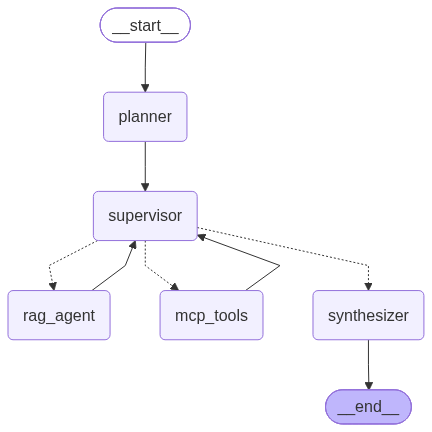

In [2]:
from agent.graph import build_graph

graph = build_graph()   # real LLM + Vector Search retriever + bundled MCP server

# Visualize the compiled graph.
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [3]:
def run(question):
    result = graph.invoke({"messages": [{"role": "user", "content": question}]})
    print("PLAN:")
    for i, step in enumerate(result["plan"]):
        print(f"  {i}. {step}")
    print("\nSTEP RESULTS:")
    for i, r in enumerate(result["step_results"]):
        print(f"  {i}. {r}")
    print("\nFINAL ANSWER:\n", result["messages"][-1].content)
    return result

In [4]:
# 1) Retrieval-only query
_ = run("What was the net income in 2023?")

[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


PLAN:
  0. Find the net income for fiscal year 2023

STEP RESULTS:
  0. Net income attributable to owners of the parent in fiscal year 2023 was ¥1,107 billion [source: annual_report.pdf, p.2].

FINAL ANSWER:
 The net income in 2023 was ¥1,107 billion [source: annual_report.pdf, p.2].


In [5]:
# 2) Computation-only query
_ = run("What is 15% of 2.4 billion?")

[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


PLAN:
  0. Retrieve the value of 2.4 billion
  1. Compute 15% of 2.4 billion

STEP RESULTS:
  0. Not found in documents.
  1. 0.15 * 2.4e9 = 3.6e+08

FINAL ANSWER:
 15% of 2.4 billion is 360 million (3.6e+08), which was calculated as 0.15 * 2.4e9.


In [6]:
# 3) Combined query — full step-by-step execution trace
combined = run("What was the revenue in 2023, and what would a 10% increase look like?")

[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


PLAN:
  0. Find the net revenue for fiscal year 2023
  1. Compute the net revenue for 2023 * 1.10

STEP RESULTS:
  0. Net revenue in FY2023 was ¥16.91 trillion [source: annual_report.pdf, p.2].
  1. 16.91 * 1.10 = 18.601

FINAL ANSWER:
 The revenue in 2023 was ¥16.91 trillion [source: annual_report.pdf, p.2]. A 10% increase would result in a revenue of ¥18.601 trillion.


In [7]:
# Detailed streaming trace of the combined query (node-by-node updates).
for update in graph.stream(
    {"messages": [{"role": "user", "content": "What was the revenue in 2023, and what would a 10% increase look like?"}]},
    stream_mode="updates",
):
    print(update)

{'planner': {'plan': ['Find the net revenue for fiscal year 2023', 'Compute the net revenue for 2023 * 1.10'], 'current_step_index': 0, 'step_results': []}}


{'supervisor': {'next_agent': 'rag_agent'}}
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


{'rag_agent': {'step_results': ['Net revenue in FY2023 was ¥16.91 trillion [source: annual_report.pdf, p.2].'], 'current_step_index': 1}}


{'supervisor': {'next_agent': 'mcp_tools'}}


{'mcp_tools': {'step_results': ['Net revenue in FY2023 was ¥16.91 trillion [source: annual_report.pdf, p.2].', '16.91 * 1.10 = 18.601'], 'current_step_index': 2}}
{'supervisor': {'next_agent': 'synthesizer'}}


{'synthesizer': {'final_answer': 'The revenue in 2023 was ¥16.91 trillion [source: annual_report.pdf, p.2]. A 10% increase would result in a revenue of ¥18.601 trillion, which is an increase of ¥1.691 trillion from the original revenue.', 'messages': [AIMessage(content='The revenue in 2023 was ¥16.91 trillion [source: annual_report.pdf, p.2]. A 10% increase would result in a revenue of ¥18.601 trillion, which is an increase of ¥1.691 trillion from the original revenue.', additional_kwargs={}, response_metadata={}, id='f92bd5b9-9438-4041-a15c-a95c0ab6f5f7', tool_calls=[], invalid_tool_calls=[])]}}


## Part 2 — Test the deployed endpoint (Task 2.4)

Deploy first with `uv run python deployment/deploy.py`, then run these cells.

In [8]:
# 1) Raw curl call
import subprocess, json
payload = json.dumps({"messages": [{"role": "user", "content": "What was the net income in 2023?"}]})
cmd = [
    "curl", "-s", f"{DATABRICKS_HOST}/serving-endpoints/{ENDPOINT_NAME}/invocations",
    "-H", f"Authorization: Bearer {DATABRICKS_TOKEN}",
    "-H", "Content-Type: application/json",
    "-d", payload,
]
print(subprocess.run(cmd, capture_output=True, text=True).stdout)

[{"messages": [{"content": "What was the net income in 2023?", "additional_kwargs": {}, "response_metadata": {}, "type": "human", "name": null, "id": "4bc88f79-f99c-42f3-bb07-e6a5e6534010"}, {"content": "The net income in 2023 was \u00a51,107 billion, as reported in the annual report [source: annual_report.pdf, p.2].", "additional_kwargs": {}, "response_metadata": {}, "type": "ai", "name": null, "id": "f6737438-1797-4697-84aa-219cdf15ea0a", "tool_calls": [], "invalid_tool_calls": [], "usage_metadata": null}], "plan": ["Find the net income for fiscal year 2023"], "current_step_index": 1, "step_results": ["Net income attributable to owners of the parent in fiscal year 2023 was \u00a51,107 billion [source: annual_report.pdf, p.2]."], "next_agent": "synthesizer", "final_answer": "The net income in 2023 was \u00a51,107 billion, as reported in the annual report [source: annual_report.pdf, p.2]."}]


In [9]:
# 2) OpenAI Python SDK call (parsed)
import openai
client = openai.OpenAI(api_key=DATABRICKS_TOKEN, base_url=f"{DATABRICKS_HOST}/serving-endpoints")
resp = client.chat.completions.create(
    model=ENDPOINT_NAME,
    messages=[{"role": "user", "content": "What was the net income in 2023?"}],
)

# This models-from-code endpoint returns the raw LangGraph state, which the OpenAI
# SDK wraps as [ChatCompletion(choices=None, messages=[...])] — the answer is the
# last message, not resp.choices. Handle both shapes for portability.
def parse_answer(resp):
    item = resp[0] if isinstance(resp, list) else resp
    if getattr(item, "choices", None):
        return item.choices[0].message.content
    return item.messages[-1]["content"]

print(parse_answer(resp))

The net income in 2023 was ¥1,107 billion [source: annual_report.pdf, p.2].


In [10]:
# 3) The same 3 test queries against the deployed endpoint, with latency (cold vs warm)
queries = [
    "What was the net income in 2023?",
    "What is 15% of 2.4 billion?",
    "What was the revenue in 2023, and what would a 10% increase look like?",
]
for q in queries:
    t0 = time.monotonic()
    r = client.chat.completions.create(model=ENDPOINT_NAME, messages=[{"role": "user", "content": q}])
    dt = time.monotonic() - t0
    print(f"[{dt:6.2f}s] {q}\n  -> {parse_answer(r)}\n")

[  4.08s] What was the net income in 2023?
  -> The net income in 2023 was ¥1,107 billion, as reported in the annual report [source: annual_report.pdf, p.2].



[  7.38s] What is 15% of 2.4 billion?
  -> 15% of 2.4 billion is 360 million (3.6e+08), which was calculated as 0.15 * 2.4e9. Note that the value of 2.4 billion could not be found in documents, but this did not affect the computation.



[  4.91s] What was the revenue in 2023, and what would a 10% increase look like?
  -> The revenue in 2023 was ¥16.91 trillion [source: annual_report.pdf, p.2]. A 10% increase would result in a revenue of ¥18.601 trillion, which is an increase of ¥1.691 trillion from the original revenue.



## Part 3 — Client SDK demo (Task 3.2)

In [11]:
from client.sdk import DocumentAnalystClient, AnalystClientError

sdk = DocumentAnalystClient(ENDPOINT_NAME)
assert sdk.health_check() is True
print("endpoint READY")

endpoint READY


In [12]:
# ask()
print(sdk.ask("What was the net income in 2023?"))

The net income in 2023 was ¥1,107 billion [source: annual_report.pdf, p.2].


In [13]:
# ask_streaming() — print chunks as they arrive
for chunk in sdk.ask_streaming("What was the revenue in 2023, and what would a 10% increase look like?"):
    print(chunk, end="", flush=True)
print()

The revenue in 2023 was ¥16.91 trillion [source: annual_report.pdf, p.2]. A 10% increase would result in a revenue of ¥18.601 trillion, which is an increase of ¥1.691 trillion from the original revenue.

In [14]:
# Simulate a timeout
try:
    DocumentAnalystClient(ENDPOINT_NAME, timeout=0.001).ask("hello")
except TimeoutError as e:
    print("TimeoutError:", e)

TimeoutError: Request to 'asad-document-analyst' timed out after 0.04s (timeout=0.001s)


In [15]:
# Simulate the endpoint being unavailable -> retry/backoff then AnalystClientError
try:
    DocumentAnalystClient("nonexistent-endpoint", max_retries=2).ask("hello")
except AnalystClientError as e:
    print("AnalystClientError:", e, "| status:", e.status_code, "| request_id:", e.request_id)

AnalystClientError: Endpoint 'nonexistent-endpoint' returned 404: The given endpoint does not exist, please retry after checking the specified model and version deployment exists. | status: 404 | request_id: 5c0b206d-ff12-4e97-b601-835d1e2baddb
